In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d, griddata
from itertools import product
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
import glob
from math import log2

defaultPars = {'figure.figsize': (5, 4), 'lines.markersize' : 4, 'axes.titlesize' : 13, 'font.size' : 13,
               'axes.labelsize' : 16, 'xtick.labelsize' : 13, 'ytick.labelsize' : 13, 'legend.fontsize' : 10,
               "text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 'font.serif':'Times New Roman', "savefig.dpi" : 300,
               'contour.linewidth' : 2.0, 'lines.linewidth' : 2.0, 'axes.grid' : True,
               'grid.linewidth' : 0.5, 'grid.color' : 'lightgray', 'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars) #Figure resolution

### Load Recast Data

In [12]:
# inputFiles = ['../CMS-EXO-20-004/scanResults_scalar_cms_nocut.pcl', 
#               '../CMS-EXO-20-004/scanResults_pseudoscalar_cms_nocut.pcl']

inputFiles = ['../CMS-EXO-20-004/scalar_3000_150_cms_exo_20_004.pcl',
              '../CMS-EXO-20-004/pseudoscalar_3000_150_cms_exo_20_004.pcl']


# inputFiles = ['/home/camila/Workstation-backup/pcl-files/scanResults_scalar_cms_nocut.pcl',
#               '/home/camila/Workstation-backup/pcl-files/scanResults_pseudoscalar_cms_nocut.pcl']

# inputFiles = ['../CMS-EXO-20-004/AuxInfo/CMS-EXO-20-004-data/DMsimp_spin-1_Monojet_DF.pcl']



dfs = [pd.read_pickle(i) for i in inputFiles]
recastData = pd.concat(dfs, ignore_index=True)

In [13]:
recastData

,Data-takingperiod,Luminosity (1/fb),bin_250.0_280.0,bin_250.0_280.0_ErrorPlus,bin_250.0_280.0_ErrorMinus,bin_280.0_310.0,bin_280.0_310.0_ErrorPlus,bin_280.0_310.0_ErrorMinus,bin_310.0_340.0,bin_310.0_340.0_ErrorPlus,...,Electronveto,Muonveto,Tauveto,Bjetveto,Photonveto,"$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad",LeadingAK4jet$p_{T}>100$GeV,LeadingAK4jet$\eta<2.4$,HCALmitigation(jets),HCALmitigation($\phi^{miss}$)
0,2016,36.0,0.004167,0.000244,0.000244,0.002817,0.000203,0.000203,0.002958,0.000219,...,0.569342,0.569342,0.554166,0.472063,0.468213,0.464246,0.454376,0.454376,0.454376,0.454376
1,2017,41.5,0.004791,0.000266,0.000266,0.003795,0.000241,0.000241,0.003771,0.000244,...,0.566118,0.566118,0.550762,0.473326,0.469905,0.466771,0.460140,0.460140,0.460140,0.460140
2,2018,59.7,0.005180,0.000277,0.000277,0.004426,0.000262,0.000262,0.003744,0.000258,...,0.567891,0.567799,0.550579,0.474561,0.471276,0.467182,0.456819,0.456819,0.435939,0.382490
3,2016,36.0,0.004740,0.000287,0.000287,0.004193,0.000284,0.000284,0.003701,0.000249,...,0.580603,0.580600,0.564289,0.483660,0.479829,0.478427,0.470993,0.470993,0.470993,0.470993
4,2017,41.5,0.005936,0.000327,0.000327,0.004776,0.000285,0.000285,0.003850,0.000252,...,0.560020,0.559988,0.543378,0.459362,0.456454,0.453880,0.445747,0.445747,0.445747,0.445747
5,2018,59.7,0.006314,0.000323,0.000323,0.005432,0.000314,0.000314,0.004409,0.000282,...,0.574133,0.574133,0.554394,0.474200,0.470626,0.467532,0.457624,0.457624,0.434981,0.385945


In [14]:
recastData[recastData['$m_{DM}$']==150]

,Data-takingperiod,Luminosity (1/fb),bin_250.0_280.0,bin_250.0_280.0_ErrorPlus,bin_250.0_280.0_ErrorMinus,bin_280.0_310.0,bin_280.0_310.0_ErrorPlus,bin_280.0_310.0_ErrorMinus,bin_310.0_340.0,bin_310.0_340.0_ErrorPlus,...,Electronveto,Muonveto,Tauveto,Bjetveto,Photonveto,"$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad",LeadingAK4jet$p_{T}>100$GeV,LeadingAK4jet$\eta<2.4$,HCALmitigation(jets),HCALmitigation($\phi^{miss}$)
0,2016,36.0,0.004167,0.000244,0.000244,0.002817,0.000203,0.000203,0.002958,0.000219,...,0.569342,0.569342,0.554166,0.472063,0.468213,0.464246,0.454376,0.454376,0.454376,0.454376
1,2017,41.5,0.004791,0.000266,0.000266,0.003795,0.000241,0.000241,0.003771,0.000244,...,0.566118,0.566118,0.550762,0.473326,0.469905,0.466771,0.460140,0.460140,0.460140,0.460140
2,2018,59.7,0.005180,0.000277,0.000277,0.004426,0.000262,0.000262,0.003744,0.000258,...,0.567891,0.567799,0.550579,0.474561,0.471276,0.467182,0.456819,0.456819,0.435939,0.382490
3,2016,36.0,0.004740,0.000287,0.000287,0.004193,0.000284,0.000284,0.003701,0.000249,...,0.580603,0.580600,0.564289,0.483660,0.479829,0.478427,0.470993,0.470993,0.470993,0.470993
4,2017,41.5,0.005936,0.000327,0.000327,0.004776,0.000285,0.000285,0.003850,0.000252,...,0.560020,0.559988,0.543378,0.459362,0.456454,0.453880,0.445747,0.445747,0.445747,0.445747
5,2018,59.7,0.006314,0.000323,0.000323,0.005432,0.000314,0.000314,0.004409,0.000282,...,0.574133,0.574133,0.554394,0.474200,0.470626,0.467532,0.457624,0.457624,0.434981,0.385945


### Get all model points

In [15]:
models = []
mCols = ['Coupling', 'Mode', '$m_{med}$', '$m_{DM}$', '$g_{DM}$', '$g_{q}$']
for row in recastData[mCols].values:
    m = dict(zip(mCols, row.tolist()))
    if m not in models:
        models.append(m)

print('%i models loaded.' %len(models))

2 models loaded.


### Get models parameters

In [16]:
parameters = {label : list(set([m[label] for m in models])) for label in mCols}
for k,v in parameters.items():
    if len(v) == 1:
        parameters[k] = v[0]
print(parameters)

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in parameters.items() if k not in ['$m_{med}$','$m_{DM}$']])
print(textstr)

{'Coupling': ['Scalar', 'Pseudoscalar'], 'Mode': 'DM+QCDjets', '$m_{med}$': 3000.0, '$m_{DM}$': 150.0, '$g_{DM}$': 1.0, '$g_{q}$': 1.0}
Coupling = ['Scalar', 'Pseudoscalar']
Mode = DM+QCDjets
$g_{DM}$ = 1.0
$g_{q}$ = 1.0


### Filter parameters

In [17]:
paramFilter = {
    'Mode' : 'DM+QCDjets',
    '$m_{med}$' : 3000.,
    '$m_{DM}$' : 150.,
    '$g_{DM}$' : 1.,
#     '$g_{q}$' : .25,
    'Data-takingperiod' : 2017
}

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in paramFilter.items()])
dfModel = recastData.loc[(recastData[list(paramFilter)] == pd.Series(paramFilter)).all(axis=1)]

In [18]:
dfModel.T

,1,4
Data-takingperiod,2017,2017
Luminosity (1/fb),41.5,41.5
bin_250.0_280.0,0.004791,0.005936
bin_250.0_280.0_ErrorPlus,0.000266,0.000327
bin_250.0_280.0_ErrorMinus,0.000266,0.000327
bin_280.0_310.0,0.003795,0.004776
bin_280.0_310.0_ErrorPlus,0.000241,0.000285
bin_280.0_310.0_ErrorMinus,0.000241,0.000285
bin_310.0_340.0,0.003771,0.00385
bin_310.0_340.0_ErrorPlus,0.000244,0.000252


The efficiency for the $i$-th bin, $\epsilon_{i}$, is given by:

$$ \epsilon_{i} = \frac{n^{i}_{s}}{\sigma_{T}\mathcal{L}},   $$
where $n^{i}_{s}$ is the number of events in the correspondent bin, $\sigma_{T}$ is the total cross-section, and $\mathcal{L}$ is the integrated luminosity.  

### Auxiliar functions for plotting

In [19]:
def getBins(dfModel,rightBin = 1400.):
    
    bins = {c : eval(c.split('_')[1]) for c in dfModel.columns if ("bin_" in c and not 'Error' in c)}
    binsError = {c : eval(c.split('_')[1]) for c in dfModel.columns if ("bin_" in c and 'ErrorPlus' in c)}    
    binCenter = (np.array(list(bins.values()))+np.diff(list(bins.values())+[rightBin])/2).tolist()    
    binLeft = [bins[c] for c in bins]+[rightBin] 
    
    return bins,binsError,binCenter,binLeft


def getEfficiencies(dfSingle, bins, binsError):
    
    xsec = dfSingle['Total xsec (pb)'].iloc[0]
    lumi = dfSingle['Luminosity (1/fb)'].iloc[0]
    eff = {}
    ns = {c: dfSingle[c].iloc[0] for c in bins}
    nsErr = {c : dfSingle[c].iloc[0] for c in binsError}
    effErr = {}
    for c in bins:
        if ns[c] == 0:
            eff[c] = 0
            effErr[f'{c}_Error'] = 0
        else:
            eff[c] = dfSingle[c].iloc[0]/(xsec*1e3*lumi)
            effErr[f'{c}_Error'] = nsErr[f'{c}_ErrorPlus']*eff[c]/ns[c]
    
    return eff, effErr

### Plot Efficiencies

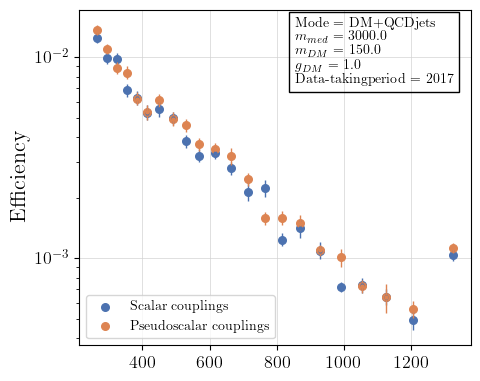

In [25]:
bins, binsError, binCenter, binLeft = getBins(dfModel)

fig, ax = plt.subplots()

data = pd.DataFrame(columns=['Scalar','Pseudoscalar'])
dataError = pd.DataFrame(columns=['Scalar','Pseudoscalar'])


colors = {label : sns.color_palette('deep')[i] for i,label in enumerate(data.keys())}    

for label in dfModel['Coupling']:
    dfSingle = dfModel[dfModel['Coupling'] == label]
    data[label], dataError[label] = getEfficiencies(dfSingle, bins, binsError)
 
    eff = np.array([data[label][c] for c in bins])
    effErr = np.array([dataError[label][f'{c}_Error'] for c in bins])
    
    ax.scatter(x=binCenter, y=eff, s=30, color=colors[label], label=r'%s couplings' %(label))
    ax.errorbar(binCenter, eff, yerr=effErr, marker='.', 
                   elinewidth=1.0, drawstyle='steps-mid',linewidth=0.0, color=colors[label])

    
ax.set_yscale('log')
ax.text(.55, .78, textstr, fontsize=10, bbox=dict(facecolor='none', edgecolor='black'), 
           transform=plt.gca().transAxes)



ax.set_ylabel('Efficiency')
ax.legend()
# plt.grid()
plt.tight_layout()
plt.savefig('efficiencies_spin0_3000_150_onshell.png')

plt.show()

In [22]:
dataScalar = dfModel[dfModel['Coupling'] == 'Scalar']
dataPseudo = dfModel[dfModel['Coupling'] == 'Pseudoscalar']

In [ ]:
# Setting the index with mass pairs
dataScalar = pd.DataFrame([dataScalar.set_index(['$m_{med}$', '$m_{DM}$'])[c] for c in dfModel if 'Efficiency' in c])
dataPseudo = pd.DataFrame([dataPseudo.set_index(['$m_{med}$', '$m_{DM}$'])[c] for c in recastData if 'Efficiency' in c])

In [24]:
data

,Scalar,Scalar_onshell,Pseudoscalar,Pseudoscalar_onshell
bin_250.0_280.0,0.012479,NaN,0.013644,NaN
bin_280.0_310.0,0.009885,NaN,0.010977,NaN
bin_310.0_340.0,0.009821,NaN,0.008850,NaN
bin_340.0_370.0,0.006836,NaN,0.008363,NaN
bin_370.0_400.0,0.006253,NaN,0.006205,NaN
bin_400.0_430.0,0.005294,NaN,0.005306,NaN
bin_430.0_470.0,0.005499,NaN,0.006084,NaN
bin_470.0_510.0,0.004957,NaN,0.004939,NaN
bin_510.0_550.0,0.003815,NaN,0.004588,NaN
bin_550.0_590.0,0.003235,NaN,0.003692,NaN
